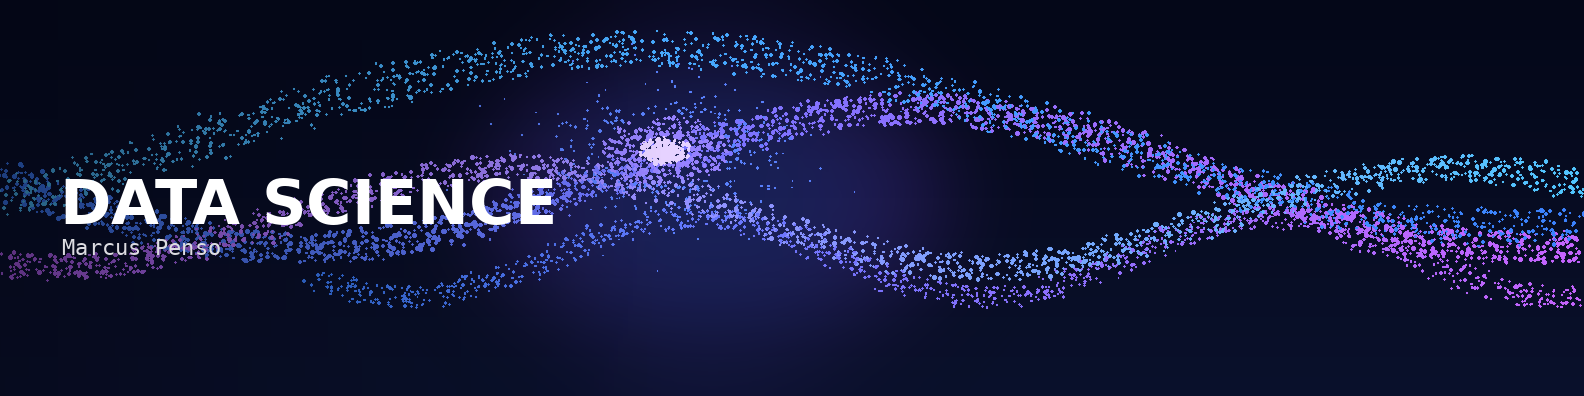

## **Projeto 1 - Análise de Dados - AirBnB - Paris**

O **Airbnb** é uma empresa americana que opera **on-line** um mercado para **estadias** e **experiências** de casas de família de curto e longo prazo.
Ela foi iniciada com a locação de um **colchão de ar** numa sala que se transformou em uma espécie de **pousada** em **2007**. No ano seguinte o **produto** foi oferecido com **café da manhã** para quem não conseguia reservas no **saturado mercado de hospedagem**. Hoje o **Airbnb** é considerada uma das maiores empresas hoteleiras do mundo sem possuir **nenhum** hotel próprio.

Em 2020 a empresa valia cerca de U$ 18 bilhões, e em 2023 contava com um pouco mais de **6000** funcionários.

Com relação à **ciência de dados**, uma das iniciativas do **Airbnb** é disponibilizar seus **dados de locação** de algumas das principais cidades do mundo. Por meio do portal [**Inside Airbnb**](https://insideairbnb.com/pt/) é possível acessá-los. No nosso caso, analisaremos os dados de locação da cidade de **Paris** na França, Europa.

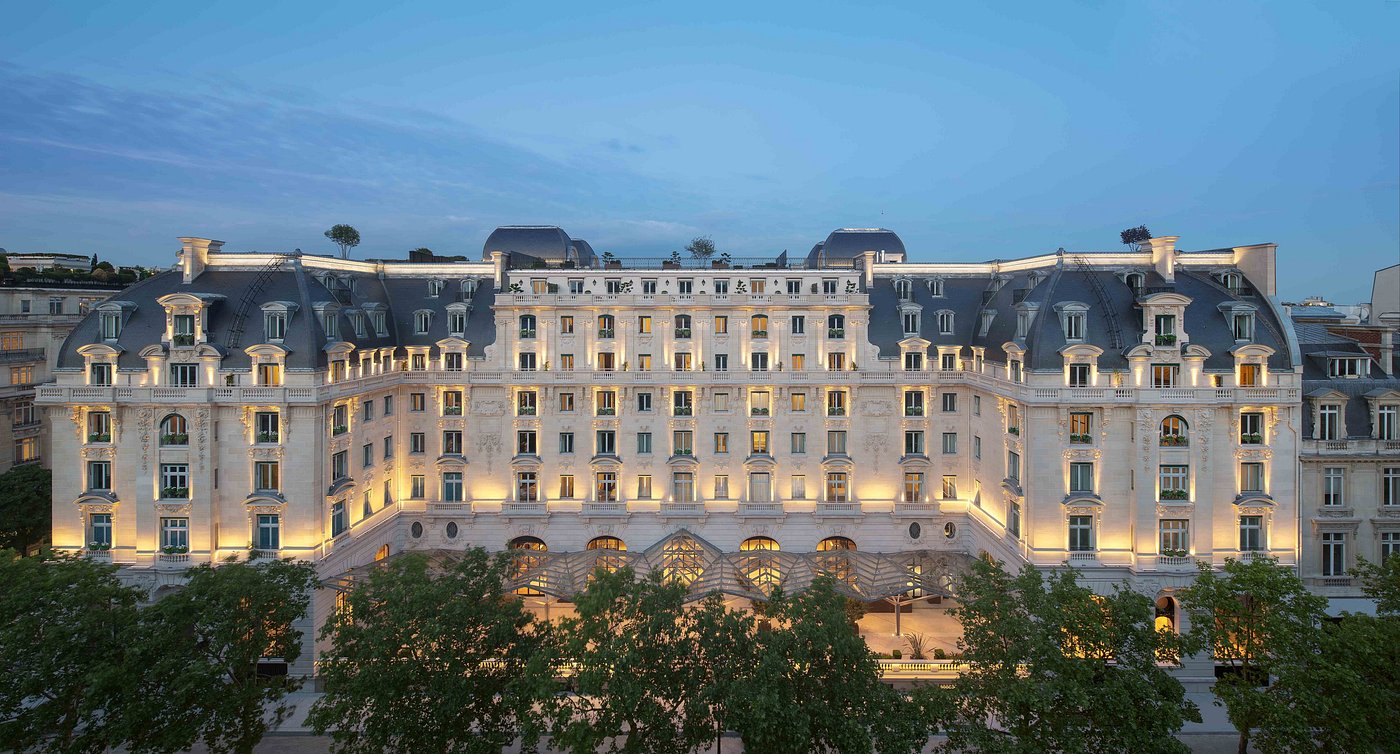

Quando se pensa na **questão turística** vale a pena destacar os principais pontos:

* Torre Eiffel e Champ de Mars (7º arrondissement — cartão-postal da cidade);
* Museu do Louvre e Jardim das Tulherias (1º arrondissement — maior museu de arte do mundo);
* Montmartre: Basílica de Sacré-Coeur e Place des Tertres, com pintores de rua que fazem caricaturas e retratam a cidade (18º arrondissement);
* Bairro do Marais: ruas charmosas com lojas de roupas, decoração e cosméticos, boulangeries, e o famoso falafel do L'As du Falafel (3º e 4º arrondissements);
* Quartier Latin e Saint-Germain-des-Prés: região da universidade Sorbonne, com bares estudantis, livrarias, o Panteão, e cafés históricos como Les Deux Magots e Café de Flore (5º e 6º arrondissements);
* Passeio de barco pelo Rio Sena, passando por baixo das pontes históricas da cidade;
* Champs-Élysées e Arco do Triunfo (8º arrondissement — compras de luxo e monumento histórico).

Vamos iniciar nosso projeto **importando** as bibliotecas necessárias para a **análise exploratória dos dados**.

In [ ]:
# 1 - Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.rcParams["font.family"] = "sans- serif"

**Acessando a base de dados:**
  * Iniciaremos verificando as principais informações da base de dados.

In [ ]:
# 2 - Acessando a base de dados
df= pd.read_csv ("https://raw.githubusercontent.com/MarcusZanol/projeto-airbnb-paris/refs/heads/main/listings.csv")

In [ ]:
# 3 - Verificando a quantidade de linhas e colunas
df.shape

(77679, 19)

In [ ]:
# 4 - Verificando os nomes das colunas
df.columns

Index(['id', 'name', 'host_id', 'host_profile_id', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [ ]:
# 5 - Verificando os tipos de dados das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77679 entries, 0 to 77678
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              77679 non-null  int64  
 1   name                            77679 non-null  object 
 2   host_id                         77679 non-null  int64  
 3   host_profile_id                 77412 non-null  float64
 4   host_name                       77419 non-null  object 
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   77679 non-null  object 
 7   latitude                        77679 non-null  float64
 8   longitude                       77679 non-null  float64
 9   room_type                       77679 non-null  object 
 10  price                           48402 non-null  float64
 11  minimum_nights                  77679 non-null  int64  
 12  number_of_reviews               

**Significado** de cada coluna:

* id - número de id gerado cuja finalidade é identificar o imóvel;
* name - nome da propriedade anunciada;
* host_id - número de id do proprietário (anfitrião) da propriedade;
* host_name - nome do anfitrião;
* neighbourhood_group - esta coluna não possui valor válido;
* neighbourhood - nome do bairro;
* latitude - coordenada da latitude do imóvel;
* longitude - coordenada da longitude do imóvel;
* room_type - informação sobre o tipo de quarto que é ofertado;
* price - preço para alugar o imóvel;
* minimum_nights - período mínimo de noites por reserva;
* number_of_reviews - número de reviews que o imóvel possui;
* last_reviews - data do último review;
* reviews_per_month - quantidade de reviews por mês;
* calculated_host_listings_count - quantidade de imóveis do mesmo anfitrião;
* availability_365 - número de dias disponíveis em 365 dias.

In [ ]:
# 6 - Visualizando as primeiras linhas da base de dados
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3109,zen and calm,3631,1.462506e+18,Anne,NaN,Observatoire,48.83191,2.31870,Entire home/apt,160.0,2,10,2026-05-31,0.10,1,336,3,7511409139079
1,7397,MARAIS - 2ROOMS APT - 2/4 PEOPLE,2626,1.462506e+18,Franck,NaN,Hôtel-de-Ville,48.85909,2.35315,Entire home/apt,628.0,1,400,2026-05-03,2.16,1,247,20,7510400829623
2,7964,Sunny apartment with balcony,22155,1.462507e+18,Anaïs,NaN,Opéra,48.87417,2.34245,Entire home/apt,215.0,7,5,2015-09-14,0.03,1,31,0,7510903576564
3,9952,Paris petit coin douillet,33534,1.462507e+18,Elisabeth,NaN,Popincourt,48.86373,2.37093,Entire home/apt,171.0,1,59,2026-06-08,0.37,1,77,3,7511101582862
4,11265,Elegant appartment in Montmartre,41718,1.462507e+18,Sylvie,NaN,Buttes-Montmartre,48.88494,2.33997,Entire home/apt,219.0,7,43,2025-09-29,0.35,1,203,8,7511801401834


Identificando **valores NaN (nulos ou ausentes)**:
* A verificação de valores **nulos** é imprescindível para compreensão de sua existência, assim como sua correção, para evitar os possíveis erros na análise.

In [ ]:
# 7 - Verificando a existência de valores NaN (nulos / ausentes)
df.isnull().sum()


,0
id,0
name,0
host_id,0
host_profile_id,267
host_name,260
neighbourhood_group,77679
neighbourhood,0
latitude,0
longitude,0
room_type,0


Como observado acima, a coluna **neighbourhood_group** está com todos os seus valores **ausentes**, ou seja, **100%** de valores **nulos**. Nesse caso, iremos **excluí-la**. Em relação aos valores ausentes nas colunas (host_profile_id, host_name, last_review, reviews_per_month, license), será necessária uma investigação mais aprofundada para decidir o melhor tratamento, que não será o foco *deste projeto*. Contudo, as linhas com valores ausentes na coluna `price` serão removidas.

Excluindo a coluna **neighbourhood_group**
* Utilizaremos o método **drop** para exclusão da coluna.

In [ ]:
# 8 - Excluindo a coluna neighbourhood_group com o método drop
df.drop("neighbourhood_group", axis = 1, inplace = True)

Excluindo os valores **NaN**
* Utilizaremos o método **dropna** para a exclusão das linhas com **valores ausentes** pela coluna **price**.

In [ ]:
# 9 - Excluindo as linhas com valores nan pela coluna price (onde não há preços), com o método dropna
df.dropna(subset=["price"], inplace = True)

Verificando o **resumo estatístico**:
* Uma vez que realizamos as **exclusões** necessárias, verificaremos o **resumo estatístico** para uma primeira compreensão sobre seus **valores**. Utilizaremos o método **describe** para isso.

In [ ]:
# 10 - Verificando o resumo estatístico das colunas com valores numéricos
df[["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]].describe().round()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48402.0,48402.0,48402.0,40060.0,48402.0,48402.0
mean,321.0,8.0,39.0,1.0,20.0,195.0
std,833.0,27.0,78.0,2.0,57.0,118.0
min,3.0,1.0,0.0,0.0,1.0,1.0
25%,131.0,1.0,2.0,0.0,1.0,79.0
50%,206.0,2.0,13.0,1.0,1.0,204.0
75%,342.0,4.0,45.0,2.0,8.0,305.0
max,97003.0,365.0,4589.0,55.0,754.0,365.0


Olhando para o **resumo estatístico**, de acordo com a coluna **minimum_nights**, podemos perceber que 50% das locações ocorrem em até 2 diárias, e que **75%** ocorrem em um período de até **4 dias**. Parece que temos **2 grupos** específicos de locatários. Além disso, de acordo com a coluna **price** para essa primeira análise, o valor da **mediana (50%)** das locações é de **206** Euros, sendo que existe um valor máximo de **97003** Euros. Vamos realizar algumas **visualizações gráficas** para melhor **compreensão dos dados**.

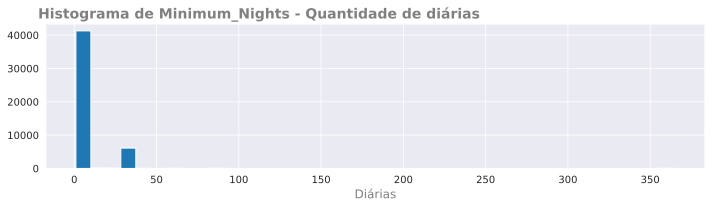

In [ ]:
# 11 - Plotando histograma da coluna "minimum_nights"
sns.set_style ("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
ax.hist("minimum_nights", data = df, bins = 40)
ax.text(-22, 45000, "Histograma de Minimum_Nights - Quantidade de diárias",
        color = "grey", fontsize = 14, fontweight = "semibold")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()

O gráfico de histograma acima nos mostra uma grande concentração de quantidades de locação abaixo de 10 diárias. Embora o gráfico não permita identificar visualmente o valor exato dentro desse intervalo, essa concentração é consistente com o valor de 4 diárias encontrado no nosso resumo estatístico. Outra possibilidade de visualização sobre a distribuição dos dados é o gráfico de boxplot.

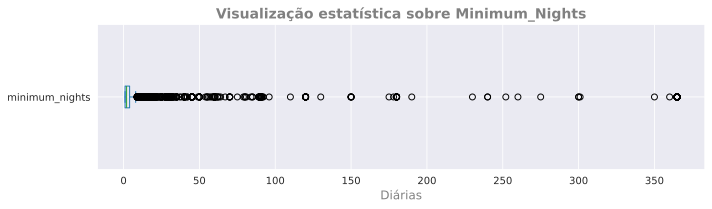

In [ ]:
# 12 - Plotando o boxplot da coluna "minimum_nights"
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
df.minimum_nights.plot(kind = "box", vert = False, ax = ax)
ax.set_title("Visualização estatística sobre Minimum_Nights", color = "grey", fontsize = 14, fontweight = "bold")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()

In [ ]:
# 13 - Quantidade de locações por período de locação até 30 dias:
print(f"Quantidade total de locações até 30 dias pela coluna minimum_nights: {(len(df[df.minimum_nights <= 30]))}.")
print("Percentual de correspondência da base de dados: {:.2f}%.".format((len(df[df.minimum_nights <= 30]) / df.shape[0])*100))

Quantidade total de locações até 30 dias pela coluna minimum_nights: 47679.
Percentual de correspondência da base de dados: 98.51%.


Com o gráfico **boxplot** acima podemos **ratificar** que a quantidade mínima de noites pela coluna **minimum_nights** está concentrada nos primeiros valores. Portanto, existe uma boa quantidade de **outliers**, que são valores discrepantes do padrão. De forma mais detalhada, em conjunto com o **resumo estatístico**, verificamos ainda que as locações até **30** noites são responsáveis por cerca de 98% das ocorrências.

Para melhorarmos nossa **análise exploratória**, uma boa prática é gerar uma **cópia** da base de dados para nossos **tratamentos** necessários.

In [ ]:
# 14 - Gerando uma cópia da base de dados
df_copia = df.copy()

Aprofundaremos nossos tratamentos excluindo os valores **outliers** da coluna **minimum_nights**, ou seja, valores superiores a **30 diárias**. Vamos, ainda, visualizar a **distribuição** desta nova base de dados.

In [ ]:
# 15 - Removendo os valores "outliers" da coluna minimum_nights
df_copia.drop(df_copia[df_copia.minimum_nights > 30].index, axis = 0, inplace = True)

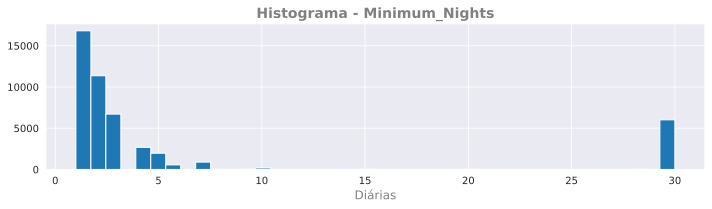

In [ ]:
# 17 - Plotando um histograma da coluna "minimum_nights" sem "outliers"
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
ax.hist("minimum_nights", data = df_copia, bins = 40)
ax.set_title("Histograma - Minimum_Nights", color = "grey", fontsize = 14, fontweight = "semibold")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()
plt.savefig("Histograma.jpeg")

Percebemos nitidamente que temos **alguns grupos** de locatários concentrados em pontos específicos. O grupo mais expressivo se concentra entre **1 e 3 dias**, sendo a maioria absoluta dos anúncios. Além dele, identificamos uma pequena concentração próxima a 7 dias e outra bem definida em 30 dias. Vamos realizar uma nova separação na base de dados considerando esses grupos.

In [ ]:
# 18 - Separando a base de dados
df_7 = df_copia.loc[df_copia.minimum_nights <= 7]
df_30 = df_copia.loc[df_copia.minimum_nights > 7]

Visualizaremos os dados estatísticos com o **boxplot** para os dois grupos.

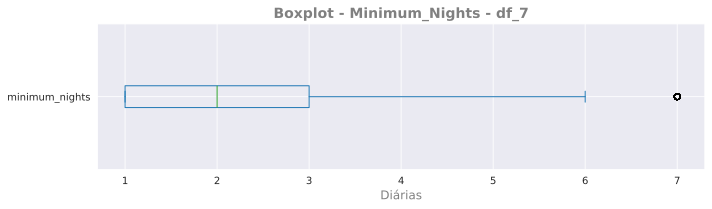

In [ ]:
# 19 - Boxplot da coluna "minimum_nights" para a base df_7
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
df_7.minimum_nights.plot(kind = "box", vert = False, ax = ax)
ax.set_title("Boxplot - Minimum_Nights - df_7", color = "grey", fontsize = 14, fontweight = "semibold")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()

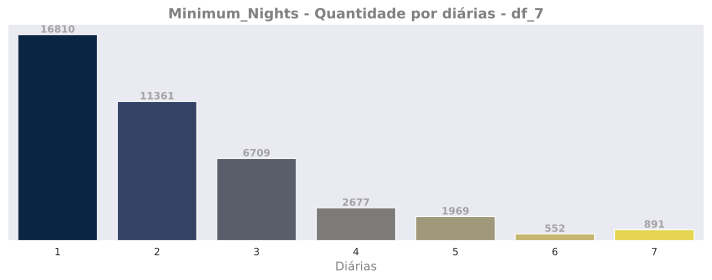

In [ ]:
# 20 - Countplot com a contagem por dia
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 4), dpi = 150)
barras = sns.countplot(x = "minimum_nights", data = df_7, ax = ax, palette = "cividis",
                        hue = "minimum_nights", legend = False)

for i in barras.patches:
    ax.annotate(int(i.get_height()),
                xy = (i.get_x() + i.get_width() / 2,
                      i.get_height()),
                color = "#A2A1A3",
                fontweight = "semibold",
                ha = "center",
                va = "bottom")

plt.gca().axes.get_yaxis().set_visible(False)
ax.set_title("Minimum_Nights - Quantidade por diárias - df_7", color = "grey", fontsize = 14, fontweight = "semibold")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
ax.set_ylabel("")
plt.tight_layout()

Percebemos nitidamente nos dois gráficos acima que a grande maioria das locações deste grupo ocorre nos **2 primeiros dias**, inclusive, sendo este o valor da **mediana** no **boxplot**.

Verificaremos agora como estão as principais **informações, distribuições e valores** por **bairros** de ambas as bases. Começaremos pela base **df_7**.

In [ ]:
# 21 - Verificando os nomes dos bairros da base df_7 com o método unique
df_7.neighbourhood.unique()

array(['Observatoire', 'Hôtel-de-Ville', 'Opéra', 'Popincourt',
       'Buttes-Montmartre', 'Gobelins', 'Buttes-Chaumont', 'Luxembourg',
       'Louvre', 'Reuilly', 'Élysée', 'Batignolles-Monceau', 'Vaugirard',
       'Entrepôt', 'Panthéon', 'Bourse', 'Ménilmontant', 'Passy',
       'Temple', 'Palais-Bourbon'], dtype=object)

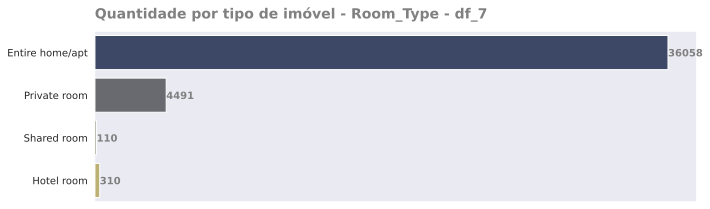

In [ ]:
# 22 - Verificando a quantidade de tipo de imóvel para locação na base df_7
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 3), dpi = 150)
barras = sns.countplot(y = "room_type", data = df_7, ax = ax, orient = "h", palette = "cividis",
                        hue = "room_type", legend = False)

for i in barras.patches:
    ax.annotate(int(i.get_width()),
                xy = (((i.get_width() + 5) - (i.get_height())),
                      i.get_x() + i.get_y() + (i.get_height() / 2)),
                va = "center_baseline", color = "grey", fontweight = "bold",
                ha = "left")

plt.gca().axes.get_xaxis().set_visible(False)
ax.text(0.7, -0.8, "Quantidade por tipo de imóvel - Room_Type - df_7",
        color = "grey", fontsize = 14, fontweight = "semibold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Room_Type - df_7.jpeg")

A maior quantidade de locações para a base **df_7** está entre **apartamentos ou casas individuais (entire home/apt**) e **quartos individuais (Private room**). Hotel completo e **quarto compartilhado** têm locações mínimas na cidade de **Paris**.

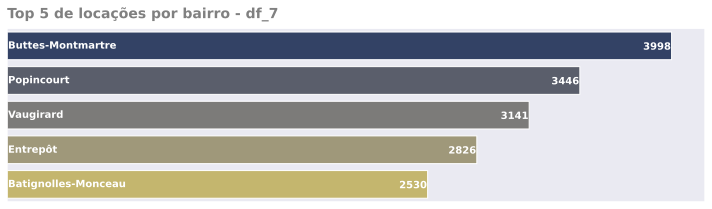

In [ ]:
# 23 - Plotando a quantidade de locações por bairros
imoveis = df_7.groupby(["neighbourhood"]).size().sort_values(ascending = False)[:5]
imoveis = pd.DataFrame(imoveis, columns = ["values"])
imoveis.reset_index(inplace = True)

fig, ax = plt.subplots(figsize=(10, 3), dpi = 150)
sns.set_style("darkgrid")
barras = sns.barplot(x = "values", y = "neighbourhood", data = imoveis, ax = ax,
                      palette = "cividis", hue = "neighbourhood", legend = False)

for i in barras.patches:
    ax.annotate(int(i.get_width()),
                xy = ((i.get_width() - (i.get_height() * 5)),
                      i.get_x() + i.get_y() + (i.get_height() / 2)),
                va = "center_baseline", color = "white", fontweight = "bold",
                ha = "right")

for i in range(len(imoveis)):
    bairro = imoveis.iloc[i, 0]
    valor = imoveis.iloc[i, 1]
    ax.text(valor - valor + 5, i, bairro, fontsize = 10, fontweight = "bold", color = "white", va = "center")

plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
ax.text(0, -0.8, "Top 5 de locações por bairro - df_7", fontsize = 14, color = "grey", fontweight = "bold")

ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Locações por bairro - df_7.jpeg")

As maiores quantidades de locações estão em **Buttes-Montmartre** e **Popincourt**, bairros conhecidos por sua vida boêmia e cultural — **Montmartre (ao norte da cidade)**, famoso pela Basílica de Sacré-Coeur, e **Popincourt** (região que abrange parte do 11º arrondissement), **mais central-leste**, próximo a áreas boêmias como Oberkampf.

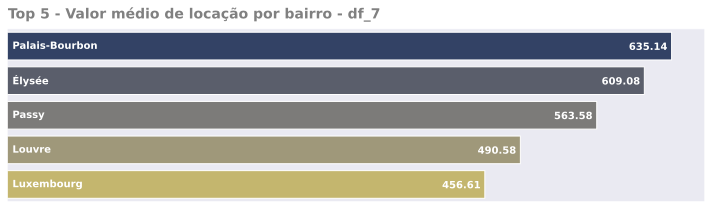

In [ ]:
# 24 - Visualizando a "média" de preços por bairros ordenando pelo maior valor
price_mean = round(df_7.groupby(["neighbourhood"]).price.mean().sort_values(ascending = False)[:5], 2)
price_mean = pd.DataFrame(price_mean)
price_mean.reset_index(inplace = True)

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 3), dpi = 150)

barras = sns.barplot(x = "price", y = "neighbourhood", data = price_mean, ax = ax,
                      palette = "cividis", hue = "neighbourhood", legend = False)

for i in barras.patches:
    ax.annotate(i.get_width(),
                xy = ((i.get_width() - (i.get_height() * 5)),
                      i.get_x() + i.get_y() + (i.get_height() / 2)),
                va = "center_baseline",
                color = "white",
                fontweight = "bold",
                ha = "right")

for i in range(len(price_mean)):
    bairro = price_mean.iloc[i, 0]
    valor = price_mean.iloc[i, 1]
    ax.text(valor - valor + 5, i, bairro, fontsize = 10, fontweight = "bold", color = "white", va = "center")

plt.gca().axes.get_yaxis().set_visible(False)
plt.gca().axes.get_xaxis().set_visible(False)
ax.text(0.7, -0.8, "Top 5 - Valor médio de locação por bairro - df_7", fontsize = 14, color = "grey", fontweight = "bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Valor médio por locação - df_7.jpeg")

Os maiores valores médios para locação estão concentrados nos bairros centrais e nobres de Paris, como Palais-Bourbon e Élysée — regiões associadas a instituições políticas (Assembleia Nacional, Palácio do Eliseu) e pontos turísticos de prestígio, como os Champs-Élysées. Bairros como Passy, Louvre e Luxembourg completam o top 5, todos conhecidos por seu caráter histórico, turístico ou residencial de alto padrão. Por fim, analisaremos os dados da base df_30.

DF_30

In [ ]:
# 25 - Verificando os nomes dos bairros da base df_30 com o método unique
df_30.neighbourhood.unique()

array(['Popincourt', 'Opéra', 'Observatoire', 'Reuilly', 'Entrepôt',
       'Hôtel-de-Ville', 'Panthéon', 'Vaugirard', 'Élysée', 'Passy',
       'Ménilmontant', 'Buttes-Montmartre', 'Bourse', 'Buttes-Chaumont',
       'Gobelins', 'Temple', 'Palais-Bourbon', 'Luxembourg', 'Louvre',
       'Batignolles-Monceau'], dtype=object)

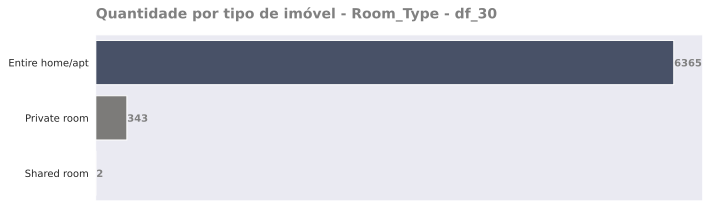

In [ ]:
# 26 - Verificando a quantidade de tipo de imóvel para locação na base df_30
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 3), dpi = 150)
barras = sns.countplot(y = "room_type", data = df_30, ax = ax, orient = "h", palette = "cividis",
                        hue = "room_type", legend = False)

for i in barras.patches:
    ax.annotate(int(i.get_width()),
                xy = (((i.get_width() + 5) - (i.get_height())),
                      i.get_x() + i.get_y() + (i.get_height() / 2)),
                va = "center_baseline", color = "grey", fontweight = "bold",
                ha = "left")

plt.gca().axes.get_xaxis().set_visible(False)
ax.text(0.7, -0.8, "Quantidade por tipo de imóvel - Room_Type - df_30", color = "grey",
        fontsize = 14, fontweight = "semibold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Room_Type - df_30.jpeg")

É mais visível ainda a opção pela **individualidade** frente ao **compartilhamento** para quem loca o imóvel por **30 dias**, cerca de **99%** das locações.

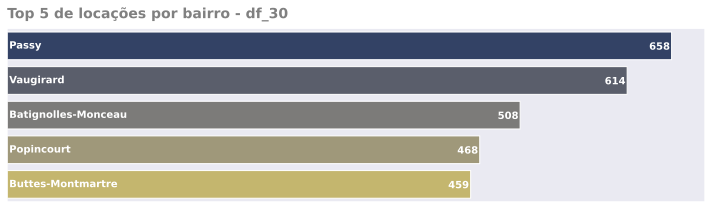

In [ ]:
# 27 - Exibindo a "quantidade" de imóveis locados por bairro:
imoveis = df_30.groupby(["neighbourhood"]).size().sort_values(ascending = False)[:5]
imoveis = pd.DataFrame(imoveis, columns = ["values"])
imoveis.reset_index(inplace = True)

fig, ax = plt.subplots(figsize=(10, 3), dpi = 150)
sns.set_style("darkgrid")
barras = sns.barplot(x = "values", y = "neighbourhood", data = imoveis, ax = ax, palette = "cividis",
                      hue = "neighbourhood", legend = False)

for i in barras.patches:
    ax.annotate(int(i.get_width()),
                xy = ((i.get_width() - (i.get_height() * 2)),
                      i.get_x() + i.get_y() + (i.get_height() / 2)),
                va = "center_baseline", color = "white", fontweight = "bold",
                ha = "right")

for i in range(len(imoveis)):
    bairro = imoveis.iloc[i, 0]
    valor = imoveis.iloc[i, 1]
    ax.text(valor - valor + 2, i, bairro, fontsize = 10, fontweight = "bold", color = "white", va = "center")

plt.gca().axes.get_xaxis().set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
ax.text(0, -0.8, "Top 5 de locações por bairro - df_30", fontsize = 14, color = "grey", fontweight = "bold")

ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Locações por bairro - df_30.jpeg")

Os principais destinos de quem loca por 30 dias estão espalhados por diferentes regiões de Paris, sem uma concentração geográfica única. Destacam-se **Passy (oeste)**, **Vaugirard (sudoeste)**, **Batignolles-Monceau (noroeste)**, **Popincourt (leste)** e **Buttes-Montmartre (norte)** — indicando que locações de longa duração não estão restritas a bairros turísticos centrais, mas distribuídas por áreas residenciais de diferentes perfis pela cidade.

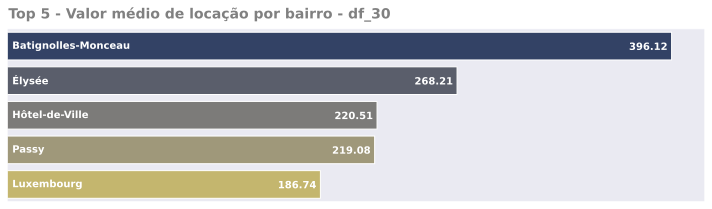

In [ ]:
# 28 - Visualizando a "média" de preços por bairros ordenando pelo maior valor
price_mean = round(df_30.groupby(["neighbourhood"]).price.mean().sort_values(ascending = False)[:5], 2)
price_mean = pd.DataFrame(price_mean)
price_mean.reset_index(inplace = True)
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 3), dpi = 150)

barras = sns.barplot(x = "price", y = "neighbourhood", data = price_mean, ax = ax, palette = "cividis",
                      hue = "neighbourhood", legend = False)

for i in barras.patches:
    ax.annotate(i.get_width(),
                xy = ((i.get_width() - (i.get_height() * 3)),
                      i.get_x() + i.get_y() + (i.get_height() / 2)),
                va = "center_baseline",
                color = "white",
                fontweight = "bold",
                ha = "right")

for i in range(len(price_mean)):
    bairro = price_mean.iloc[i, 0]
    valor = price_mean.iloc[i, 1]
    ax.text(valor - valor + 3, i, bairro, fontsize = 10, fontweight = "bold", color = "white", va = "center")

plt.gca().axes.get_yaxis().set_visible(False)
plt.gca().axes.get_xaxis().set_visible(False)
ax.text(0.7, -0.8, "Top 5 - Valor médio de locação por bairro - df_30", fontsize = 14, color = "grey", fontweight = "bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Valor médio por locação - df_30.jpeg")

Os maiores valores médios de locação estão distribuídos por toda a cidade, sendo o de maior destaque o bairro de **Batignolles-Monceau**, a noroeste.

**Concluindo:**

A análise exploratória nos forneceu uma boa compreensão de que existem 2 grupos distintos de locação na base de dados: um voltado para estadias curtas (concentradas em 1 a 2 dias, representando a maior parte da base df_7) e outro voltado para estadias longas, próximas de 30 dias (base df_30), sugerindo perfis de uso distintos — turismo de curta duração versus locação de temporada ou residência temporária.

Em relação aos bairros, notamos que as regiões mais procuradas variam conforme o tipo de estadia: locações curtas se concentram em bairros como Buttes-Montmartre e Popincourt, conhecidos por sua vida cultural e boêmia, enquanto locações longas se distribuem por bairros como Passy e Vaugirard, sem uma concentração geográfica única. Já os valores médios mais altos aparecem em bairros centrais e nobres, como Palais-Bourbon e Élysée, associados a pontos turísticos de prestígio e instituições políticas da cidade.

A apresentação priorizou informações gráficas fluidas e diretas, direcionando a compreensão para os tipos de imóveis locados, as principais quantidades de locações por bairro e seus maiores valores médios por locação. Há ainda espaço para outras análises, como correlações entre preço e localização, ou um estudo mais aprofundado sobre a sazonalidade das reservas ao longo do ano. Entretanto, como análise inicial, houve satisfação com o resultado apresentado.